In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## K-means
The first unsupervised tecnique is **K-means**;a model that separates data into clusters based in means of groups in data.the algorithm uses the **centroid** instance as referene for each class,beigh fundamental is affinity meansures.
We have two main types of K-means for clustering:

- Hard clustering : Assing a instance to a cluster
- Soft clustering : Put a score in each instance based on clusters affinity.



for start our studies,we will use make_blobs dataset.this dataset is for work with unsupervised tecs:

Text(0, 0.5, 'x2')

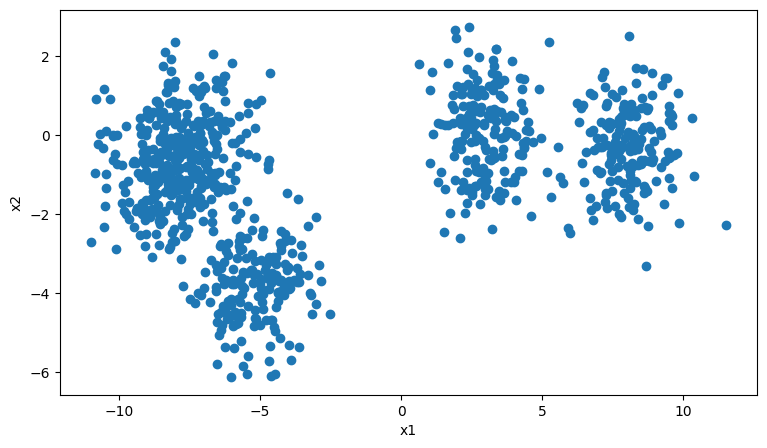

In [2]:
from sklearn.datasets import make_blobs

x,y = make_blobs(n_samples=900,centers=5,cluster_std=1)

plt.figure(figsize=(9,5))
plt.scatter(x[:,0],x[:,1])
plt.xlabel('x1')
plt.ylabel('x2')

In [3]:
from sklearn.model_selection import train_test_split


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [4]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=4)
k_predict = k_means.fit_predict(x_train)

You could assign the centroid to start previously;

In [5]:
centroids = np.array([])
k_means2 = KMeans(init=centroids)

### Inertia and Silhouette
Inertia measures how close one instance is of its cluster centroid in mean.it is influenced directly by the number of **K**;More k : decreases the distances between instances while Less k :increases the distances.

In other side,Silhouette coeficient computes the distance between clusters according the chose of **K**. 

In [6]:
from sklearn.metrics import silhouette_score

#inertia
print(k_means.score,k_means.inertia_)

#sil
print(f'Silhouette: {silhouette_score(x_train,k_means.labels_)}')

<bound method _BaseKMeans.score of KMeans(n_clusters=4)> 1593.2895465949068
Silhouette: 0.5995170877976297


We also have the **MiniBatchMeans**; support to online learning.The algorithm computes the centroid of clusters at each iteration and updates it using the parans:

- Batch_size
- Max_iter

In [7]:
from sklearn.cluster import MiniBatchKMeans

mb_means = MiniBatchKMeans(n_clusters=4)
mb_means.fit(x_train)

,n_clusters,4
,init,'k-means++'
,max_iter,100
,batch_size,1024
,verbose,0
,compute_labels,True
,random_state,None
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,'auto'


### Using K-Means for diferents purpouses
KMeans algorithm is a versatile model,which allow us use in diferents ways for find groups in our data.

#### 1.Image Segmentation
We can divide a image in mutiple segments according its groups of pixels.this tecnique has 2 forms:

1. Semantic Segmentation
2. Instance Segmentation



In [8]:
from matplotlib.image import imread
import os

image = imread('C:\\Users\\augusto\\Downloads\\duke-inferno-and-everflame-mansion-honkai-star-rail.webp')
image = image.astype(np.float32) / 255
image.shape



(575, 1024, 3)

In [9]:
print(image.min(), image.max())

0.0 1.0


In [10]:
x_image = image.reshape(-1,3)
k_means_image = KMeans(n_clusters=2).fit(x_image)

segmented_img = k_means_image.cluster_centers_[k_means_image.labels_]
segmented_img = segmented_img.reshape(image.shape)

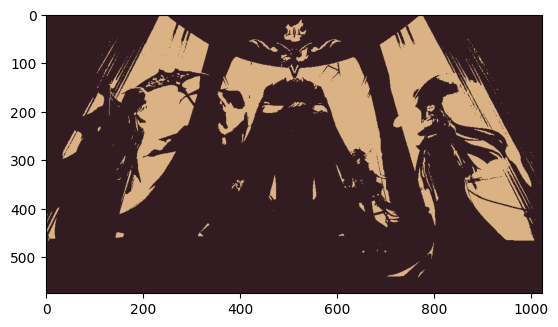

In [11]:
plt.imshow(segmented_img)
plt.show()

In [12]:
def k_images(n):
    
    
    for i in range(1,5):

        k_means_image = KMeans(n_clusters=i*n).fit(x_image)

        segmented_img = k_means_image.cluster_centers_[k_means_image.labels_]
        segmented_img = segmented_img.reshape(image.shape)

        plt.figure(figsize=(10, 10))
        plt.subplot(2, 2,i)
        plt.imshow(segmented_img)
        plt.title(f'n_clusters(colors): {i*n}')
        plt.show()



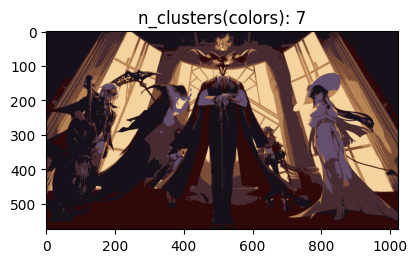

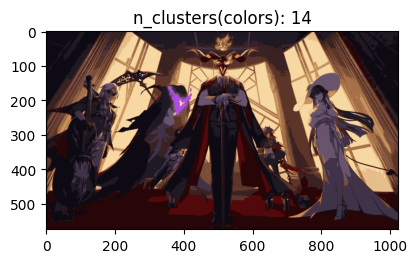

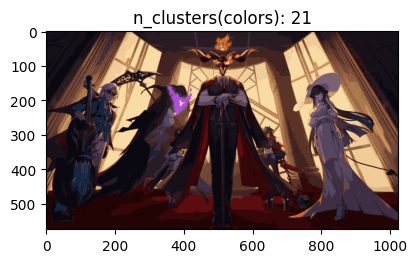

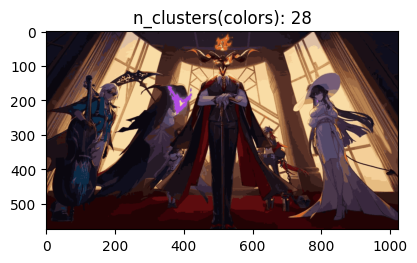

None


In [13]:

print(k_images(7))

#### 2.Preprocessing
Using clusters,we can reduce dimensionality of data before supervised training.in that way,the training becomes faster.

In [14]:
from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline

x_digits,y_digits = load_digits(return_X_y=True)

x_train_d,x_test_d,y_train_d,y_test_d = train_test_split(x_digits,y_digits)

In [15]:
from sklearn.linear_model import LogisticRegression

pipeline_k = Pipeline([
    ('k_means',KMeans(n_clusters=50)),
    ('log_reg',LogisticRegression())
])

model = LogisticRegression()

pipeline_k.fit(x_train_d,y_train_d)
model.fit(x_train_d,y_train_d)




c:\Users\augusto\.vscode\Data Sci and Ml\Linear_Regression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\augusto\.vscode\Data Sci and Ml\Linear_Regression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown i

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
print(pipeline_k.score(x_test_d,y_test_d),model.score(x_test_d,y_test_d))

0.9711111111111111 0.9777777777777777


Then,you can use **GridSearch** for see how the model performs with diferents n of clusters.

#### 3.Semisupervised
We can also find clusters that corresponds better to one class.

In [17]:
Kmeans_semisupervised = KMeans(n_clusters=60)
x_digits_dist = Kmeans_semisupervised.fit_transform(x_train_d)
idx_digits = np.argmin(x_digits_dist,axis=0)
x_representative_digits = x_train_d[idx_digits]

Or label propagation:

In [18]:
def label_prop(k,model,train_set):
    y_train_d_prop = np.empty(len(x_train_d),dtype=np.int32)
    for i in range(k):
        y_train_d_prop[model.labels_ == i] = train_set[i]


We can label it to 20% most close instances

In [19]:

def k_closest_instances(k,prop):
    x_cluster_digits = x_digits_dist[np.arrange(len(x_train_d)),Kmeans_semisupervised.labels_]
    #peforms in each cluster-label

    for i in range(k):
        in_cluster = (Kmeans_semisupervised.labels_ == i)
        cluster_dist = x_cluster_digits[in_cluster]
        cutoff_distance = np.percentile(cluster_dist,prop)
        above_cutoff = (x_cluster_digits > cutoff_distance)
        x_cluster_digits[in_cluster & above_cutoff] = -1

    partially_propagated = (x_cluster_digits != -1)
    x_digits_partially_propagated = x_train_d[partially_propagated]
    y_digits_partially_propagated = y_train_d[partially_propagated]


Here,we have find the n clusters for representative data labels.

## DBScan - Density Based Spartial Clusteirng Of Applications With Noise
Dbscan explore clusters more deeply.this algorithm defines a cluster as a dense region,which is were the **core instance** stays.the core instance is one instance with constains **min_samples** instances its distance,defined by algorithm epilson paran.epilson paran defines the minimum neighborhood distance.

Basically,core instances are those who are located in dense regions(min_samples+epilson).

In [20]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

x_moons,y_moons = make_moons(n_samples=1000,noise=0.05,random_state=33)
dbscan_moons = DBSCAN(eps=0.05,min_samples=5)
dbscan_moons.fit(x_moons)


,eps,0.05
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [21]:
print(f'core indices: {len(dbscan_moons.core_sample_indices_)} \n ,{dbscan_moons.components_}')

core indices: 799 
 ,[[-0.27262619  0.96050351]
 [-0.79246498  0.60199845]
 [ 0.13324589  1.02644534]
 ...
 [ 0.16646503 -0.00825305]
 [-0.70715598  0.62173838]
 [ 0.97551508  0.12080192]]


Diferently of other Unsupervised algorithms,dbscan does not have a predict method.so we need to use its pattners of labels as inputs of other models such like Knn.

In [22]:
from sklearn.neighbors import KNeighborsClassifier
knn_dbscan = KNeighborsClassifier()

#x,y
knn_dbscan.fit(dbscan_moons.components_,dbscan_moons.labels_[dbscan_moons.core_sample_indices_])
knn_dbscan.predict_proba(x_moons)

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(1000, 7))

Or even find its classes:

In [23]:
y_moons_dist,y_moons_pred_idx = knn_dbscan.kneighbors(x_moons,n_neighbors=2)
y_moons_pred = dbscan_moons.labels_[dbscan_moons.core_sample_indices_][y_moons_pred_idx]

y_moons_pred[y_moons_dist > 0.2] = - 1
y_moons_pred.ravel()

array([0, 0, 0, ..., 0, 6, 6], shape=(2000,))

## Gaussian Mixtures


Instead of density zones,GM models assume that each each instance was generated by a gaussian distribuition with unknown parameters.

All instances generated by one Gaussian distribuition forms a cluster.

Each cluster have a weights,means and covariances,being important to compute location of new instances.

In [24]:
from sklearn.mixture import GaussianMixture
gm = GaussianMixture(n_init=10,n_components=3)
gm.fit(x_moons)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,10
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


Now,we have the variables distribuitions and its statistics:

In [25]:
print(f'''weights: {gm.weights_} \n means: {gm.means_} \n cov: {gm.covariances_} \n precisions: {gm.precisions_}
''')

weights: [0.19932834 0.20083673 0.59983494] 
 means: [[ 1.75620279 -0.04841898]
 [-0.75286385  0.54904858]
 [ 0.50118349  0.25355335]] 
 cov: [[[ 0.05020407  0.06054324]
  [ 0.06054324  0.08731206]]

 [[ 0.04850661  0.05963811]
  [ 0.05963811  0.08941989]]

 [[ 0.17705033 -0.10987839]
  [-0.10987839  0.2926958 ]]] 
 precisions: [[[121.61527501 -84.32951036]
  [-84.32951036  69.92827948]]

 [[114.530571   -76.38554375]
  [-76.38554375  62.12811904]]

 [[  7.36367053   2.7643317 ]
  [  2.7643317    4.45425025]]]



In [26]:
gm.converged_,gm.n_iter_

(True, 18)

You can set the covariance type to : "diag","tied","spherical" or "full".each determines how will be the area each clusters.

Soft and Hard Clustering:

In [27]:
#hard : i cluster
gm.predict(x_moons)[:10]

array([2, 1, 2, 2, 1, 2, 2, 1, 2, 2])

In [28]:
#soft : prob of each i cluster
gm.predict_proba(x_moons)[:10]

array([[7.53815233e-199, 3.32666248e-001, 6.67333752e-001],
       [3.04417017e-239, 9.96730329e-001, 3.26967094e-003],
       [7.15018417e-151, 1.82842753e-008, 9.99999982e-001],
       [9.19368086e-012, 2.93533741e-125, 1.00000000e+000],
       [1.06420114e-225, 9.88614853e-001, 1.13851474e-002],
       [9.02771173e-056, 6.69576316e-055, 1.00000000e+000],
       [4.48558540e-002, 6.64027684e-176, 9.55144146e-001],
       [7.86557908e-232, 9.99866749e-001, 1.33250602e-004],
       [8.26824633e-154, 7.37261317e-008, 9.99999926e-001],
       [1.70859287e-028, 1.90410925e-088, 1.00000000e+000]])

You can even generate new instances :

In [29]:
x_gm,y_gm = gm.sample(3)
print(x_gm,y_gm)

[[ 0.55791516 -0.96314162]
 [ 0.99484988  0.51766251]
 [ 1.09436746 -0.34515638]] [2 2 2]


#### Anomaly Detection With Gaussian Mixtures

For it,we try to find instances in low density regions.

In our example,we will the define this intances as 4% of data a use it as thereshold for outliers.

In [36]:
print(np.round(gm.score_samples(x_moons)[:30],3))

[-2.137 -0.199 -1.779 -1.741 -0.011 -1.609 -2.248 -0.652 -1.824 -1.491
 -0.618  0.102 -1.5   -1.462 -1.572 -1.705  0.16  -1.56   0.018 -0.756
 -1.22  -1.228 -0.363 -1.808 -0.266 -0.981 -1.838 -1.589 -0.608 -2.198]


In [30]:
densities = gm.score_samples(x_moons) 
theresold_density = np.percentile(densities,4)
anomalies = x_moons[densities < theresold_density]

Like other unsupersvised models,Gm has the **n_clusters**.so how we select a number of clusters without arbitrary?

You could compare the metrics **Aic** and **Bic** which measures the information criterion and compares it with diferents numbers of clusters.it seems like the  _sillouete_ in Kmeans.

In [31]:
def info_per_k(ki):

    aic_l = []
    bic_l = []

    for i in range(1,ki):

        gm_i = GaussianMixture(n_components=i)
        gm_i.fit(x_moons)

        aic_l.append(gm_i.aic(x_moons))
        bic_l.append(gm_i.bic(x_moons))
    

    plt.plot(list(range(1,ki)),aic_l,label='Aic')
    plt.plot(list(range(1,ki)),bic_l,label='Bic')

    plt.xlabel('k')
    plt.ylabel('Information')
    plt.legend()
    plt.show()

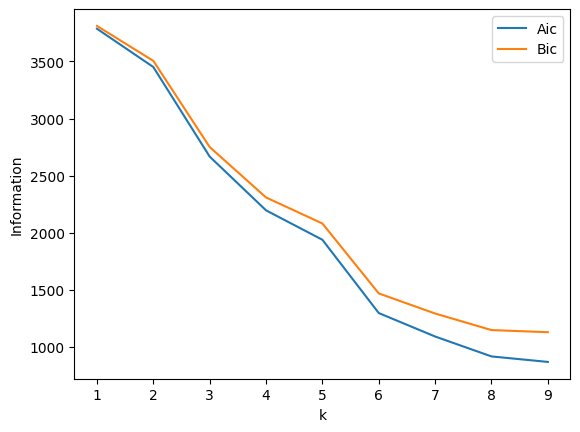

None


In [32]:
print(info_per_k(10))

### Bayesian Gaussian Mixture Models
This models select only the necessary information,based on clusters instance probability.

In [33]:
from sklearn.mixture import BayesianGaussianMixture

Bae_gm = BayesianGaussianMixture(n_components=30,n_init=10)
Bae_gm.fit(x_moons)
print(np.round(Bae_gm.weights_,4))

[0.1034 0.1261 0.001  0.001  0.1063 0.001  0.1502 0.001  0.1571 0.001
 0.001  0.1214 0.1194 0.11   0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.    ]


c:\Users\augusto\.vscode\Data Sci and Ml\Linear_Regression\.venv\Lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Just 9 Clusters are significantly needed

Using the weight_concentration_prior,we can ajust the model according the prior belief of n_clusters on data.low concentration prior will assing just a few clusters,while a high value can assing more.